In [21]:
import pandas as pd
import csv

# File paths
path_s1 = "C:/Users/Mitaksh Jhanwar/Downloads/Epoch-Alypse/6ab10eb3b23ba_student_resource/student_resource/dataset/train/train_source1.tsv"
path_s2 = "C:/Users/Mitaksh Jhanwar/Downloads/Epoch-Alypse/6ab10eb3b23ba_student_resource/student_resource/dataset/train/train_source2.tsv"
path_s3 = "C:/Users/Mitaksh Jhanwar/Downloads/Epoch-Alypse/6ab10eb3b23ba_student_resource/student_resource/dataset/train/train_source3.tsv"
path_gt = "C:/Users/Mitaksh Jhanwar/Downloads/Epoch-Alypse/6ab10eb3b23ba_student_resource/student_resource/dataset/train/train_ground_truth.tsv"

# Use quoting=csv.QUOTE_NONE to prevent stray quotes from breaking the tab separation
df_s1 = pd.read_csv(path_s1, sep="\t", quoting=csv.QUOTE_NONE)
df_s2 = pd.read_csv(path_s2, sep="\t", quoting=csv.QUOTE_NONE)
df_s3 = pd.read_csv(path_s3, sep="\t", quoting=csv.QUOTE_NONE)
df_gt = pd.read_csv(path_gt, sep="\t", quoting=csv.QUOTE_NONE)

# Strip any accidental leading/trailing whitespace from the column headers
df_s1.columns = df_s1.columns.str.strip()
df_s2.columns = df_s2.columns.str.strip()
df_s3.columns = df_s3.columns.str.strip()
df_gt.columns = df_gt.columns.str.strip()

# Verify the exact column names loaded
print("Source 1 Columns:", df_s1.columns.tolist())
print("Source 2 Columns:", df_s2.columns.tolist())
print("Source 3 Columns:", df_s3.columns.tolist())
print("Ground Truth Columns:", df_gt.columns.tolist())

Source 1 Columns: ['entity_id', 'business_name', 'business_address', 'country']
Source 2 Columns: ['entity_id', 'business_name', 'business_address', 'country']
Source 3 Columns: ['entity_id', 'business_name', 'business_address', 'country']
Ground Truth Columns: ['source1_entity_id', 'matched_entity_ids']


--- Source 1 ---
Shape: (2206821, 4)
Missing Values:
entity_id           0
business_name       0
business_address    0
country             0
dtype: int64


--- Source 2 ---
Shape: (5034616, 4)
Missing Values:
entity_id                0
business_name            2
business_address    168967
country                  0
dtype: int64


--- Source 3 ---
Shape: (5285603, 4)
Missing Values:
entity_id                0
business_name           13
business_address    175916
country                  0
dtype: int64




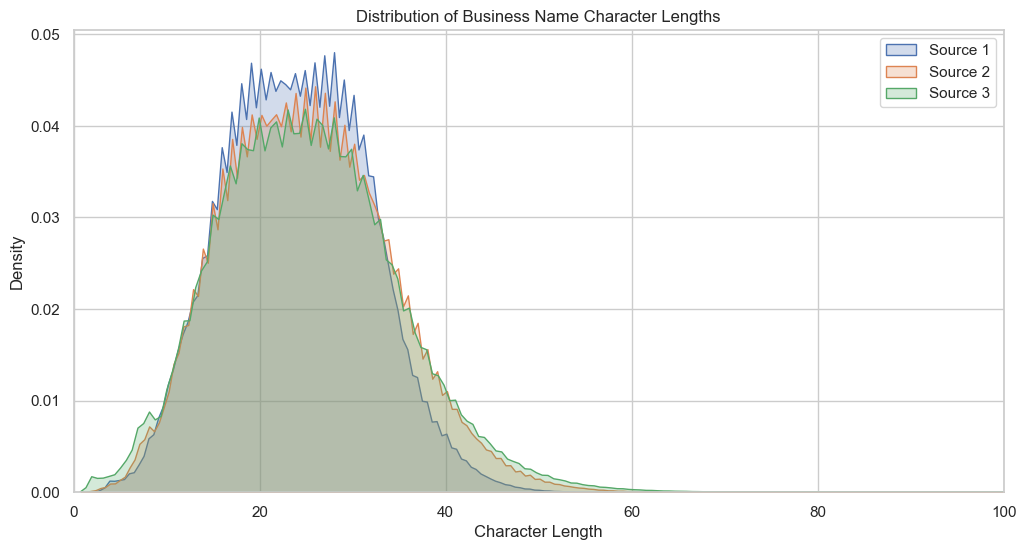

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Redefine the dictionary so it uses the clean DataFrames you just loaded
dfs = {'Source 1': df_s1, 'Source 2': df_s2, 'Source 3': df_s3}

# 1. Initial Data Profiling and Missing Values Analysis
for name, df in dfs.items():
    print(f"--- {name} ---")
    print(f"Shape: {df.shape}")
    print("Missing Values:")
    print(df.isnull().sum())
    print("\n")

# 2. Text Length and Word Count Analysis
for name, df in dfs.items():
    df['name_char_len'] = df['business_name'].astype(str).apply(len)
    df['name_word_count'] = df['business_name'].astype(str).apply(lambda x: len(x.split()))
    
    df['address_char_len'] = df['business_address'].astype(str).apply(len)
    df['address_word_count'] = df['business_address'].astype(str).apply(lambda x: len(x.split()))

# Visualize Name Lengths across sources
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_s1, x='name_char_len', label='Source 1', fill=True)
sns.kdeplot(data=df_s2, x='name_char_len', label='Source 2', fill=True)
sns.kdeplot(data=df_s3, x='name_char_len', label='Source 3', fill=True)
plt.title('Distribution of Business Name Character Lengths')
plt.xlabel('Character Length')
plt.xlim(0, 100)
plt.legend()
plt.show()

In [23]:
display(df_s1.head())

,entity_id,business_name,business_address,country,name_char_len,name_word_count,address_char_len,address_word_count
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US,19,2,38,6
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US,11,2,31,5
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US,13,3,35,5
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US,13,2,49,8
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India,23,3,52,9


In [24]:
display(df_s2.head())

,entity_id,business_name,business_address,country,name_char_len,name_word_count,address_char_len,address_word_count
0,S2-166376419,राम मार्केटिंग प्राइवेट लिमिटेड,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi",India,31,4,44,8
1,S2-764573417,-- Holloway Peak Inc Seafood,"105 ELM ST, MORGANTON, NC",US,28,5,25,5
2,S2-639257739,आदित्य प्रॉपर्टीज एलएलपी,"G-3/571, GULMOHAR COLONY, BHOPAL, Madhya Pradesh",India,24,3,48,6
3,S2-163963287,Summit Inc,"GREENSBORO, NC, 19 1/2 STARDUST TRAIL",US,10,2,37,6
4,S2-49942811,Delta Tetlecommunication Inc,"914 PIERPONT AVE, CLEVELAND, OH",US,28,3,31,5


In [25]:
display(df_s3.head())

,entity_id,business_name,business_address,country,name_char_len,name_word_count,address_char_len,address_word_count
0,S3-202863386,wilfordhancock.com,"Mack Rd, Haltom City, Texas",US,18,1,27,5
1,S3-859268022,International South Consultants Private Ltd,NaN,India,43,5,3,1
2,S3-22467283,LLC Moncada Léarning Center,"5780 Fawn Ct, Fort Worth, Texas",US,27,4,31,6
3,S3-671162755,Moyna's Coffee,"1 Ivanhoe Ave, PO Box 6009, Cincinnati, Ohio",US,14,2,44,8
4,S3-960981775,Pvt. EFS Print Ventures Ltd.,"Door No 183, 41St Cross, 22Nd Main 9Th Block J...",India,28,5,91,14


In [26]:
display(df_gt.head())

,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-7280..."


C:\Users\Mitaksh Jhanwar\AppData\Local\Temp\ipykernel_19980\2923192381.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_gt, x='match_count', palette='viridis')


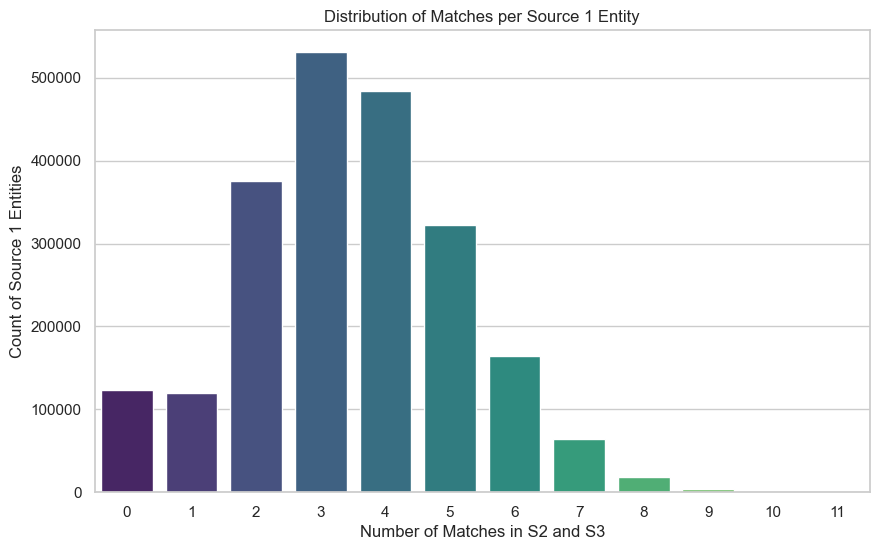

Percentage of Singletons: 5.58%


In [27]:
# Handle the comma-separated matched_entity_ids
# Fill NaNs with empty strings to represent singletons
df_gt['matched_entity_ids'] = df_gt['matched_entity_ids'].fillna('')

# Count the number of matches per Source 1 entity
df_gt['match_count'] = df_gt['matched_entity_ids'].apply(
    lambda x: 0 if x == '' else len(x.split(','))
)

# Plot the distribution of match counts
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_gt, x='match_count', palette='viridis')
plt.title('Distribution of Matches per Source 1 Entity')
plt.xlabel('Number of Matches in S2 and S3')
plt.ylabel('Count of Source 1 Entities')
plt.show()

# Calculate Singleton percentage
singleton_pct = (df_gt['match_count'] == 0).mean() * 100
print(f"Percentage of Singletons: {singleton_pct:.2f}%")

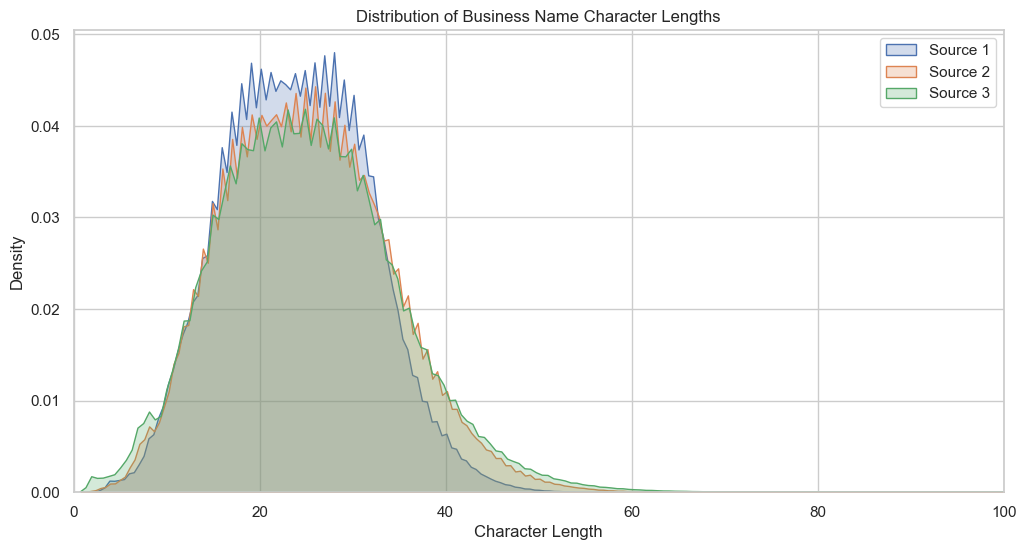

In [28]:
# Calculate character length and word counts for business names
for name, df in dfs.items():
    df['name_char_len'] = df['business_name'].astype(str).apply(len)
    df['name_word_count'] = df['business_name'].astype(str).apply(lambda x: len(x.split()))
    
    df['address_char_len'] = df['business_address'].astype(str).apply(len)
    df['address_word_count'] = df['business_address'].astype(str).apply(lambda x: len(x.split()))

# Visualize Name Lengths across sources
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_s1, x='name_char_len', label='Source 1', fill=True)
sns.kdeplot(data=df_s2, x='name_char_len', label='Source 2', fill=True)
sns.kdeplot(data=df_s3, x='name_char_len', label='Source 3', fill=True)
plt.title('Distribution of Business Name Character Lengths')
plt.xlabel('Character Length')
plt.xlim(0, 100)
plt.legend()
plt.show()

C:\Users\Mitaksh Jhanwar\AppData\Local\Temp\ipykernel_19980\529479790.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='country', palette='Set2')
C:\Users\Mitaksh Jhanwar\AppData\Local\Temp\ipykernel_19980\529479790.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='country', palette='Set2')
C:\Users\Mitaksh Jhanwar\AppData\Local\Temp\ipykernel_19980\529479790.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='country', palette='Set2')


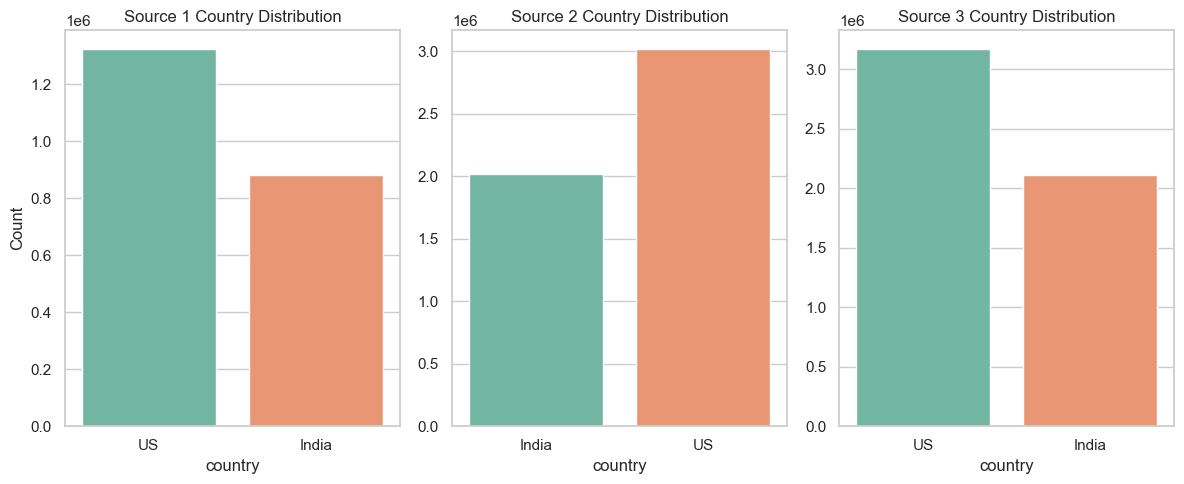

In [29]:
plt.figure(figsize=(12, 5))

for i, (name, df) in enumerate(dfs.items(), 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=df, x='country', palette='Set2')
    plt.title(f'{name} Country Distribution')
    plt.ylabel('Count' if i == 1 else '')

plt.tight_layout()
plt.show()

In [31]:
import re
from collections import Counter

def get_common_suffixes(text_series):
    def extract_last_word(text):
        # 1. Strip non-alphabet characters first
        cleaned = re.sub(r'[^a-zA-Z\s]', '', str(text))
        # 2. Split into words
        words = cleaned.split()
        # 3. Safely get the last word if it exists
        return words[-1].lower() if len(words) > 0 else ''
        
    last_words = text_series.apply(extract_last_word)
    return Counter(last_words).most_common(15)

print("Most common business name suffixes in Source 1:")
print(get_common_suffixes(df_s1['business_name']))

print("\nMost common business name suffixes in Source 2 (Noise Check):")
print(get_common_suffixes(df_s2['business_name']))

Most common business name suffixes in Source 1:
[('limited', 521915), ('llc', 377579), ('inc', 238306), ('ltd', 148595), ('pc', 47867), ('llp', 39725), ('corp', 33761), ('group', 32678), ('co', 25191), ('center', 22269), ('associates', 22165), ('pllc', 20531), ('partners', 19351), ('clinic', 18107), ('care', 16845)]

Most common business name suffixes in Source 2 (Noise Check):
[('llc', 458024), ('', 455954), ('limited', 415270), ('ltd', 344791), ('inc', 314063), ('center', 143799), ('private', 117991), ('corp', 116809), ('co', 110758), ('services', 96906), ('partners', 90793), ('group', 79844), ('holdings', 60563), ('llp', 60088), ('corporation', 53712)]


In [32]:
# Explode the ground truth to create S1-S2/S3 pairs
gt_exploded = df_gt.assign(
    matched_entity=df_gt['matched_entity_ids'].str.split(',')
).explode('matched_entity')

# Filter out singletons for this check
gt_pairs = gt_exploded[gt_exploded['matched_entity'] != '']

# Merge text data to compare
s1_text = df_s1[['entity_id', 'business_name', 'business_address']].rename(
    columns={'business_name': 's1_name', 'business_address': 's1_addr'}
)

# Combine S2 and S3 for easier merging
s2_s3_combined = pd.concat([df_s2, df_s3])[['entity_id', 'business_name', 'business_address']].rename(
    columns={'business_name': 'match_name', 'business_address': 'match_addr'}
)

# Join S1 and candidate texts
evaluation_df = gt_pairs.merge(s1_text, left_on='source1_entity_id', right_on='entity_id')
evaluation_df = evaluation_df.merge(s2_s3_combined, left_on='matched_entity', right_on='entity_id')

# Calculate exact match percentages
exact_name_matches = (evaluation_df['s1_name'].str.lower() == evaluation_df['match_name'].str.lower()).mean() * 100
exact_addr_matches = (evaluation_df['s1_addr'].str.lower() == evaluation_df['match_addr'].str.lower()).mean() * 100

print(f"Exact Name Matches in True Pairs: {exact_name_matches:.2f}%")
print(f"Exact Address Matches in True Pairs: {exact_addr_matches:.2f}%")

Exact Name Matches in True Pairs: 10.75%
Exact Address Matches in True Pairs: 7.24%


  country  total_entities  avg_matches  singleton_count  singleton_percentage
0   India          883188     3.464543            49351              5.587825
1      US         1323633     3.459057            73896              5.582816


C:\Users\Mitaksh Jhanwar\AppData\Local\Temp\ipykernel_19980\1500841301.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_gt_country[df_gt_country['match_count'] > 0], x='country', y='match_count', palette='Set2')


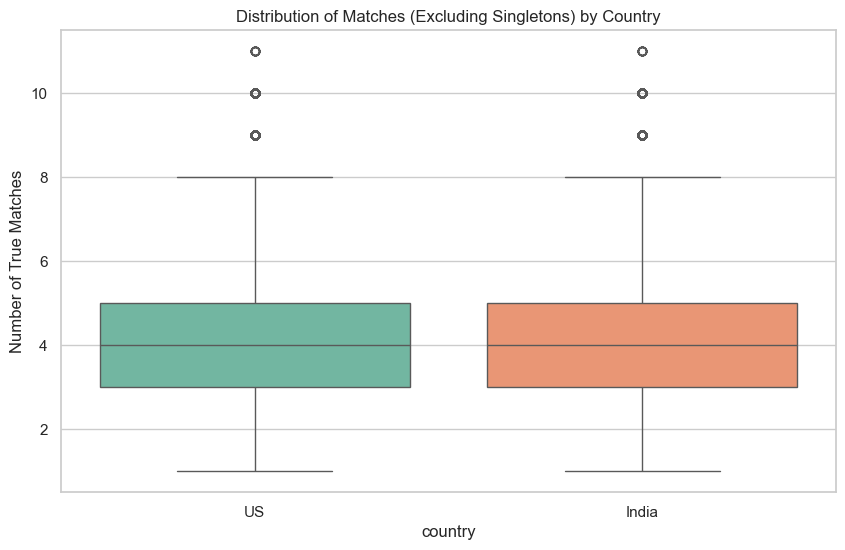

In [33]:
# Merge Source 1 country labels into the ground truth data
df_gt_country = df_gt.merge(df_s1[['entity_id', 'country']], left_on='source1_entity_id', right_on='entity_id')

# Calculate Singletons (0 matches) and Match Counts per Country
country_stats = df_gt_country.groupby('country').agg(
    total_entities=('source1_entity_id', 'count'),
    avg_matches=('match_count', 'mean'),
    singleton_count=('match_count', lambda x: (x == 0).sum())
).reset_index()

country_stats['singleton_percentage'] = (country_stats['singleton_count'] / country_stats['total_entities']) * 100

print(country_stats)

# Visualizing match distribution by country
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_gt_country[df_gt_country['match_count'] > 0], x='country', y='match_count', palette='Set2')
plt.title('Distribution of Matches (Excluding Singletons) by Country')
plt.ylabel('Number of True Matches')
plt.show()

In [34]:
import re

def analyze_address_patterns(df, country_name):
    # Filter by country if country column exists
    sub_df = df[df['country'] == country_name] if 'country' in df.columns else df
    addresses = sub_df['business_address'].astype(str).str.lower()
    
    # Keyword patterns
    landmarks = addresses.str.contains(r'\b(near|opp|opposite|beside|behind|next to)\b', regex=True, na=False)
    building_cues = addresses.str.contains(r'\b(floor|flr|bldg|building|tower|complex)\b', regex=True, na=False)
    
    # Look for a 5 or 6 digit number usually indicating a ZIP or PIN code
    postal_codes = addresses.str.contains(r'\b\d{5,6}\b', regex=True, na=False)
    
    return {
        'Landmarks (%)': landmarks.mean() * 100,
        'Building/Floor Cues (%)': building_cues.mean() * 100,
        'Postal Code Present (%)': postal_codes.mean() * 100
    }

print("--- Source 1 Address Patterns: India ---")
for key, val in analyze_address_patterns(df_s1, 'India').items():
    print(f"{key}: {val:.2f}%")

print("\n--- Source 1 Address Patterns: US ---")
for key, val in analyze_address_patterns(df_s1, 'US').items():
    print(f"{key}: {val:.2f}%")

--- Source 1 Address Patterns: India ---


C:\Users\Mitaksh Jhanwar\AppData\Local\Temp\ipykernel_19980\1179786658.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  landmarks = addresses.str.contains(r'\b(near|opp|opposite|beside|behind|next to)\b', regex=True, na=False)
C:\Users\Mitaksh Jhanwar\AppData\Local\Temp\ipykernel_19980\1179786658.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  building_cues = addresses.str.contains(r'\b(floor|flr|bldg|building|tower|complex)\b', regex=True, na=False)


Landmarks (%): 11.43%
Building/Floor Cues (%): 24.82%
Postal Code Present (%): 0.27%

--- Source 1 Address Patterns: US ---


C:\Users\Mitaksh Jhanwar\AppData\Local\Temp\ipykernel_19980\1179786658.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  landmarks = addresses.str.contains(r'\b(near|opp|opposite|beside|behind|next to)\b', regex=True, na=False)
C:\Users\Mitaksh Jhanwar\AppData\Local\Temp\ipykernel_19980\1179786658.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  building_cues = addresses.str.contains(r'\b(floor|flr|bldg|building|tower|complex)\b', regex=True, na=False)


Landmarks (%): 0.01%
Building/Floor Cues (%): 0.59%
Postal Code Present (%): 10.95%


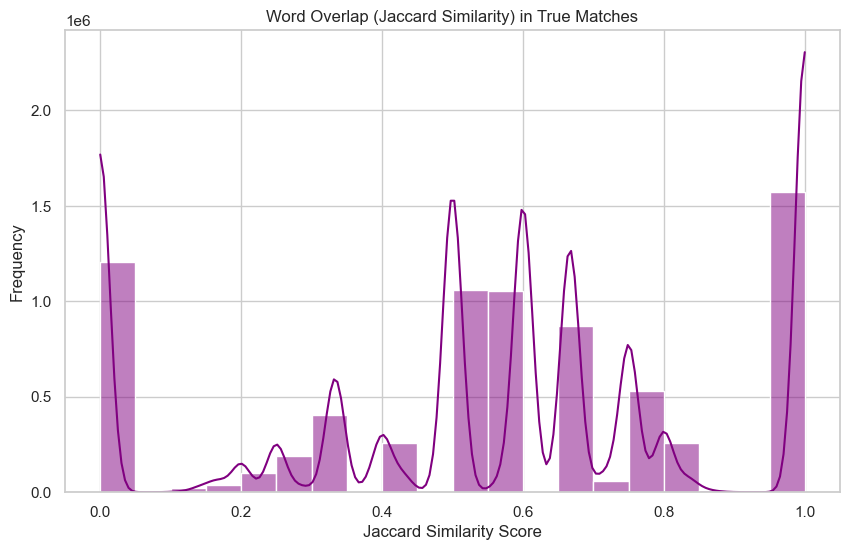

Median Jaccard Similarity of True Matches: 0.600


In [35]:
# Recreate the exploded true pairs dataframe
gt_exploded = df_gt.assign(matched_entity=df_gt['matched_entity_ids'].str.split(',')).explode('matched_entity')
gt_pairs = gt_exploded[gt_exploded['matched_entity'] != '']

# Merge text data
s1_text = df_s1[['entity_id', 'business_name']].rename(columns={'business_name': 's1_name'})
s2_s3_combined = pd.concat([df_s2, df_s3])[['entity_id', 'business_name']].rename(columns={'business_name': 'match_name'})

eval_df = gt_pairs.merge(s1_text, left_on='source1_entity_id', right_on='entity_id')
eval_df = eval_df.merge(s2_s3_combined, left_on='matched_entity', right_on='entity_id')

def jaccard_similarity(row):
    set1 = set(str(row['s1_name']).lower().split())
    set2 = set(str(row['match_name']).lower().split())
    if not set1 or not set2:
        return 0.0
    return len(set1.intersection(set2)) / len(set1.union(set2))

eval_df['name_jaccard'] = eval_df.apply(jaccard_similarity, axis=1)

# Visualize the Jaccard similarity distribution of TRUE matches
plt.figure(figsize=(10, 6))
sns.histplot(eval_df['name_jaccard'], bins=20, kde=True, color='purple')
plt.title('Word Overlap (Jaccard Similarity) in True Matches')
plt.xlabel('Jaccard Similarity Score')
plt.ylabel('Frequency')
plt.show()

print(f"Median Jaccard Similarity of True Matches: {eval_df['name_jaccard'].median():.3f}")

C:\Users\Mitaksh Jhanwar\AppData\Local\Temp\ipykernel_19980\3445666103.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  true_matches['match_source'] = true_matches['matched_entity'].str[:2]
C:\Users\Mitaksh Jhanwar\AppData\Local\Temp\ipykernel_19980\3445666103.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=true_matches, x='match_source', palette='pastel')


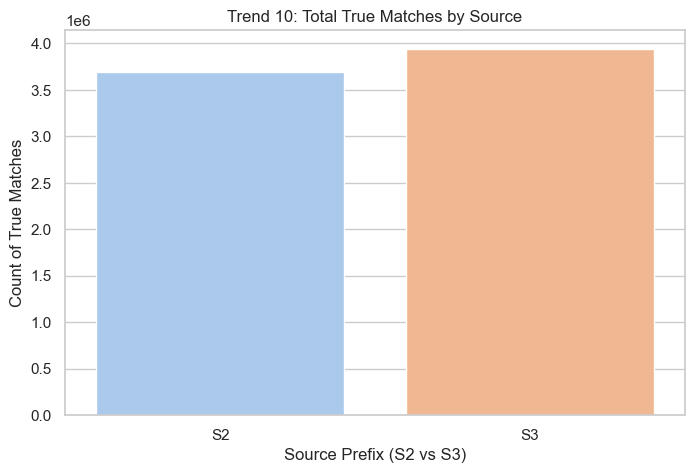

Trend 11: Multi-Match Profile (Excluding Singletons)
match_count
1      5.718875
2     18.008096
3     25.477425
4     23.234836
5     15.452151
6      7.912750
7      3.070109
8      0.896536
9      0.201817
10     0.025629
11     0.001776
Name: proportion, dtype: float64

Trend 12: Missing Address Rate per Source
Source 1: 0.00% missing addresses
Source 2: 3.36% missing addresses
Source 3: 3.33% missing addresses


In [36]:
# Explode ground truth to analyze match destinations
gt_exploded = df_gt.assign(matched_entity=df_gt['matched_entity_ids'].str.split(',')).explode('matched_entity')
true_matches = gt_exploded[gt_exploded['matched_entity'] != '']

# Extract source prefix from the matched entity ID
true_matches['match_source'] = true_matches['matched_entity'].str[:2]

plt.figure(figsize=(8, 5))
sns.countplot(data=true_matches, x='match_source', palette='pastel')
plt.title('Trend 10: Total True Matches by Source')
plt.xlabel('Source Prefix (S2 vs S3)')
plt.ylabel('Count of True Matches')
plt.show()

# 11. Multi-Match Entity Profiling
# Are entities more likely to have 1 match or multiple matches?
match_counts = df_gt[df_gt['match_count'] > 0]['match_count']
print("Trend 11: Multi-Match Profile (Excluding Singletons)")
print(match_counts.value_counts(normalize=True).sort_index() * 100)

# 12. Address Null Rate by Source
# High null rates require fallback logic in your distance calculations.
print("\nTrend 12: Missing Address Rate per Source")
for name, df in dfs.items():
    null_pct = df['business_address'].isna().mean() * 100
    print(f"{name}: {null_pct:.2f}% missing addresses")

Trend 13: Top 10 Punctuation Marks in Source 1 Names
[('.', 302837), (',', 206162), ('&', 111912), ("'", 46610), (')', 45931), ('(', 45912), ('-', 13681), ('!', 6945), ('/', 5190), ('+', 3471)]


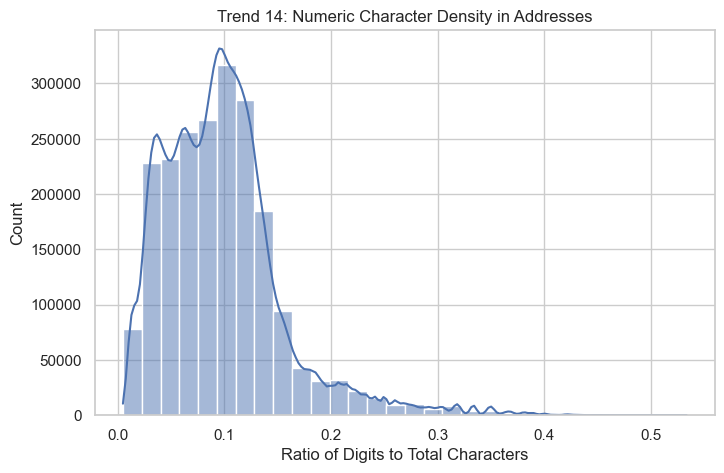


Trend 15: Most Frequent 'Stop Words' in Names
[('limited', 522340), ('private', 432503), ('llc', 355736), ('inc', 238309), ('ltd', 148599), ('pvt', 121462), ('india', 61241), ('and', 57296), ('care', 53136), ('of', 44497), ('associates', 42985), ('group', 40520), ('llp', 39726), ('center', 35433), ('partners', 35084), ('corp', 34792), ('services', 31242), ('health', 28264), ('co', 27692), ('clinic', 27586)]

Trend 16: Name Length Outliers (99th Percentile)
Source 1 99th Percentile Name Length: 42 chars
Source 2 99th Percentile Name Length: 48 chars
Source 3 99th Percentile Name Length: 50 chars


In [37]:
import string

def count_special_chars(series):
    # Combine all text, find all punctuation, count frequencies
    text_corpus = ' '.join(series.dropna().astype(str))
    char_counts = Counter(c for c in text_corpus if c in string.punctuation)
    return char_counts.most_common(10)

print("Trend 13: Top 10 Punctuation Marks in Source 1 Names")
print(count_special_chars(df_s1['business_name']))

# 14. Numeric Density in Addresses
# Addresses with high numeric density usually have street/building numbers; low density implies landmark-only.
df_s1['address_num_density'] = df_s1['business_address'].astype(str).apply(
    lambda x: sum(c.isdigit() for c in x) / len(x) if len(x) > 0 else 0
)

plt.figure(figsize=(8, 5))
sns.histplot(df_s1[df_s1['address_num_density'] > 0]['address_num_density'], bins=30, kde=True)
plt.title('Trend 14: Numeric Character Density in Addresses')
plt.xlabel('Ratio of Digits to Total Characters')
plt.show()

# 15. Frequent Stop Words in Business Names
# Words that appear too often lose their predictive power and should be penalized in TF-IDF.
from collections import Counter
all_names = ' '.join(df_s1['business_name'].dropna().astype(str).str.lower())
words = re.findall(r'\b[a-z]{2,}\b', all_names)
print("\nTrend 15: Most Frequent 'Stop Words' in Names")
print(Counter(words).most_common(20))

# 16. Outlier Detection in Text Lengths
# Identifies parsing errors where multiple columns might have bled into the name column.
print("\nTrend 16: Name Length Outliers (99th Percentile)")
for name, df in dfs.items():
    p99 = np.percentile(df['name_char_len'].dropna(), 99)
    print(f"{name} 99th Percentile Name Length: {p99:.0f} chars")

Trend 17: True Pairs with Exact Same Words but Different Order: 9.85%


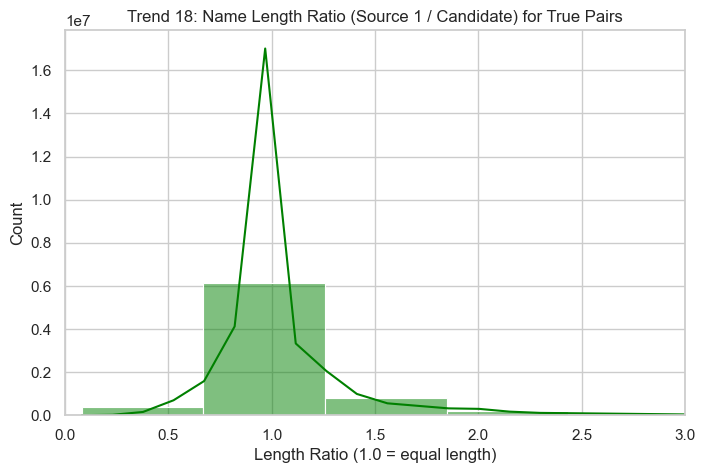


Trend 19: Average Character Similarity of True Matches: 0.782

Trend 20: Character Similarity by Match Source
Source 1 to Source 2 Average Similarity: 0.774
Source 1 to Source 3 Average Similarity: 0.790


In [38]:
# Assumes eval_df exists from previous Jaccard step
def check_transposition(row):
    str1 = str(row['s1_name']).lower().strip()
    str2 = str(row['match_name']).lower().strip()
    
    # Not an exact string match, but exact set match
    if str1 != str2 and set(str1.split()) == set(str2.split()):
        return True
    return False

eval_df['is_transposed'] = eval_df.apply(check_transposition, axis=1)
transposition_rate = eval_df['is_transposed'].mean() * 100
print(f"Trend 17: True Pairs with Exact Same Words but Different Order: {transposition_rate:.2f}%")

# 18. True Match Length Ratios
# Do true pairs have similar string lengths? 
eval_df['len_ratio'] = eval_df['s1_name'].astype(str).apply(len) / (eval_df['match_name'].astype(str).apply(len) + 1e-5)

plt.figure(figsize=(8, 5))
sns.histplot(eval_df['len_ratio'], bins=50, kde=True, color='green')
plt.title('Trend 18: Name Length Ratio (Source 1 / Candidate) for True Pairs')
plt.xlabel('Length Ratio (1.0 = equal length)')
plt.xlim(0, 3)
plt.show()

# 19. Character-Level Edit Distance Baseline (SequenceMatcher)
import difflib

def calc_string_similarity(a, b):
    # Returns a ratio from 0 to 1 based on character matching
    return difflib.SequenceMatcher(None, str(a).lower(), str(b).lower()).ratio()

eval_df['char_sim_ratio'] = eval_df.apply(lambda x: calc_string_similarity(x['s1_name'], x['match_name']), axis=1)

print(f"\nTrend 19: Average Character Similarity of True Matches: {eval_df['char_sim_ratio'].mean():.3f}")

# 20. Source 2 vs Source 3 Noise Comparison
# Which source deviates further from Source 1 in true matches?
eval_df['match_source_type'] = eval_df['matched_entity'].str[:2]
s2_sim = eval_df[eval_df['match_source_type'] == 'S2']['char_sim_ratio'].mean()
s3_sim = eval_df[eval_df['match_source_type'] == 'S3']['char_sim_ratio'].mean()

print(f"\nTrend 20: Character Similarity by Match Source")
print(f"Source 1 to Source 2 Average Similarity: {s2_sim:.3f}")
print(f"Source 1 to Source 3 Average Similarity: {s3_sim:.3f}")